# Sleep features and cognitive impairment

**The question:** do overnight physiological features predict which patients go on to
develop cognitive impairment (CI)?

**The logic of this notebook, in order:**

1. **Combine** the two feature tables into one row-per-recording table.
2. **Build a label** - time to CI for patients who converted, time censored for those who did not.
3. **Rank features** by correlation with that label, to see what carries signal.
4. **Prune** near-constant and redundant features.
5. **Classify** - contrast fast converters against long-term CI-free patients.
6. **Balance** - match on age/sex/race, because the groups differ demographically and a
   model can score well by detecting age instead of disease.
7. **Check where it works** - by subgroup, on held-out patients, and at a chosen threshold.
8. **Score it the way the Challenge does** - age-conditioned AUROC and the prevalence reward.

The recurring theme: each step exists to remove a way of being fooled by the previous
one. Section 6 exists because section 5's result turned out to be mostly age; section 7
exists because section 6's cohort is small and selected; section 8 exists because plain
AUROC rewards exactly the age shortcut section 6 spent its effort removing.

## 1. Loading the features
`all_features_standard.csv` is already one row per recording with every feature
attached, so there is no merging to do. It also carries the demographics and the
outcome columns, which earlier versions of this notebook had to pull from
`demographics.csv` separately.

# Load the feature table

In [315]:
# One self-contained table: sleep features + demographics + outcome, one row per recording.
import pandas as pd

data = pd.read_csv("all_features_standard.csv")

# The file calls the CI flag "label"; this notebook reserves that name for the survival
# time built in section 2, so rename it now. Demographics are capitalised to match the
# convention used throughout the rest of the notebook.
data = data.rename(columns={"label": "ci_event", "age": "Age", "sex": "Sex", "race": "Race"})

# demographics.csv is still needed in section 6, but only for the patient-ID column that
# links the ICD file to a recording - it holds no feature or outcome data we lack here.
demo = pd.read_csv("demographics.csv")

print("features table:", data.shape)
print("CI positives:", int(data["ci_event"].sum()), "of", len(data))

features table: (1090, 458)
CI positives: 84 of 1090


In [316]:
# What kind of columns are in here? Features are namespaced by the pipeline that
# produced them, which is the quickest way to see what the table covers.
prefixes = pd.Series([c.split("__")[0] if "__" in c else "(summary)" for c in data.columns])
prefixes.value_counts()

nk           189
rep          127
(summary)     60
arch          47
micro         35
Name: count, dtype: int64

In [317]:
# The identifier, demographic and outcome columns - everything that is NOT a feature
data[["dataset", "bids_folder", "session", "site", "site_name", "ci_event",
      "Age", "Sex", "Race", "ethnicity", "bmi", "time_to_event", "time_to_last_visit"]].head()

,dataset,bids_folder,session,site,site_name,ci_event,Age,Sex,Race,ethnicity,bmi,time_to_event,time_to_last_visit
0,standard,sub-S0001120173185,1,S0001,BIDMC,False,51,Male,White,Not Hispanic,NaN,NaN,5060
1,standard,sub-S0001112722303,1,S0001,BIDMC,False,73,Female,White,Not Hispanic,24.55,NaN,2789
2,standard,sub-S0001116945514,1,S0001,BIDMC,False,55,Male,White,Not Hispanic,NaN,NaN,4836
3,standard,sub-S0001113953169,1,S0001,BIDMC,False,57,Male,White,Not Hispanic,NaN,NaN,5064
4,standard,sub-S0001111625329,1,S0001,BIDMC,False,57,Female,Others,Hispanic,NaN,NaN,3817


In [318]:
# Sanity check: one row per recording, and the outcome columns behave as expected
print("rows:", len(data), "| unique recordings:", data[["bids_folder", "session"]].drop_duplicates().shape[0])
print("time_to_event present:", data["time_to_event"].notna().sum(), "(should equal the CI positives)")
print("time_to_last_visit present:", data["time_to_last_visit"].notna().sum(), "(should be everyone)")

rows: 1090 | unique recordings: 1090
time_to_event present: 84 (should equal the CI positives)
time_to_last_visit present: 1090 (should be everyone)


In [319]:
# Nothing to persist - the combined table is the input file. Kept as a placeholder so the
# section still ends with the table we carry forward.
data.head()

,dataset,bids_folder,session,site,site_name,ci_event,Age,Sex,Race,ethnicity,...,rep__event_dur_mean_s,rep__event_dur_median_s,rep__event_dur_max_s,rep__resp_tst_hours,rep__post_event_overshoot,rep__resp_recovery_time_s,rep__remd_rem_min,rep__remd_n_movements,rep__remd_rem_density_index,rep__remd_threshold_uv
0,standard,sub-S0001120173185,1,S0001,BIDMC,False,51,Male,White,Not Hispanic,...,16.61,12.0,73.0,6.958,1.722,5.17,109.5,2110.0,19.27,13.16
1,standard,sub-S0001112722303,1,S0001,BIDMC,False,73,Female,White,Not Hispanic,...,14.37,11.0,89.0,6.158,1.667,7.36,70.0,2025.0,28.93,17.16
2,standard,sub-S0001116945514,1,S0001,BIDMC,False,55,Male,White,Not Hispanic,...,13.22,11.0,72.0,6.233,1.454,4.97,36.0,575.0,15.97,19.19
3,standard,sub-S0001113953169,1,S0001,BIDMC,False,57,Male,White,Not Hispanic,...,13.24,11.0,82.0,6.767,2.642,7.95,63.0,1652.0,26.22,14.03
4,standard,sub-S0001111625329,1,S0001,BIDMC,False,57,Female,Others,Hispanic,...,16.07,13.0,57.0,4.308,0.753,2.51,19.5,269.0,13.79,17.13


## 2. Building the label
Neither `time_to_event` nor `time_to_last_visit` is usable alone: the first is populated
only for patients who converted, the second only measures how long someone was followed.
The label combines them into a single survival time - time to CI where it happened, time
observed where it did not.

In [320]:
# Look at time_to_event first: how many patients actually have one tells us how much of
# the label will come from conversions vs from censoring.
data["time_to_event"].describe()

count      84.000000
mean     1182.988095
std       509.540367
min       390.000000
25%       733.750000
50%      1206.500000
75%      1553.250000
max      2175.000000
Name: time_to_event, dtype: float64

In [321]:
# Survival label: time to CI where it happened, otherwise how long we watched.
# The fallback line is a guard - on this file every CI-free patient already has a
# last-visit time, so it never fires.
ci = data["ci_event"] == True
data["label"] = data["time_to_event"].where(ci, data["time_to_last_visit"])
data.loc[~ci & data["label"].isna(), "label"] = data["time_to_last_visit"].max()

print("missing label:", data["label"].isna().sum())
data.groupby("ci_event")["label"].describe()

missing label: 0


/var/folders/sr/yqwsnjy115j4s2y1dk9lc4t80000gp/T/ipykernel_49514/2100006367.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["label"] = data["time_to_event"].where(ci, data["time_to_last_visit"])


,count,mean,std,min,25%,50%,75%,max
ci_event,,,,,,,,
False,1006.0,3628.860835,1086.116387,2192.0,2684.75,3634.5,4403.00,18749.0
True,84.0,1182.988095,509.540367,390.0,733.75,1206.5,1553.25,2175.0


## 3. Which features track the label?
A cheap first look before any modelling: rank every numeric feature by its rank
correlation with the label. This is univariate and claims nothing about causation - it
exists to show whether there is signal at all, and to order the features for the pruning
step that follows.

In [322]:
# The label already lives on the feature table, so nothing to join. Keep the name `d`
# that the later sections use for "features plus demographics".
d = data

print("rows:", len(d), "| missing label:", d["label"].isna().sum())

rows: 1090 | missing label: 0


In [323]:
# Feature columns = numeric only, so the text columns (dataset, bids_folder, site,
# site_name, channel names, ci_event) drop out on their own. On top of that we remove:
#   session, ethnicity      - identifiers, not measurements
#   label, time_to_*        - the outcome itself, which would be pure leakage
#   Age, bmi                - demographics; see AGE_COLUMNS below
#
# Age is treated as something we do not have. It is held aside for EVALUATION only
# (cohort matching in section 6, the age-conditioned metrics in section 8) and must
# never reach a model. The assertion in the next cell enforces that.
AGE_COLUMNS  = ["Age", "age"]
NOT_FEATURES = ["session", "label", "time_to_event", "time_to_last_visit", "bmi"] + AGE_COLUMNS

features = data.select_dtypes("number").drop(columns=NOT_FEATURES, errors="ignore")

# Spearman = Pearson on ranks; robust to the skew in these features and needs no scipy.
rho = features.rank().corrwith(data["label"].rank())

ranking = pd.DataFrame({"spearman_r": rho, "abs_r": rho.abs(), "n": features.notna().sum()})
ranking = ranking.sort_values("abs_r", ascending=False)

print(f"{features.shape[1]} features | |r|>0.2: {(ranking.abs_r > 0.2).sum()} | |r|>0.1: {(ranking.abs_r > 0.1).sum()}")
ranking.head(25)

437 features | |r|>0.2: 24 | |r|>0.1: 129


/Users/arash_shokouhmand/Projects/PhysioNet2026/Tabular_method/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/arash_shokouhmand/Projects/PhysioNet2026/Tabular_method/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,spearman_r,abs_r,n
nk__eegc_wake_permen_sd,-0.267013,0.267013,1089
arch__arousal_idx_rem,0.263788,0.263788,1059
micro__couple_n3_preferred_phase_cos,0.258755,0.258755,433
rep__spindle_n2_amp_mean,0.258363,0.258363,1083
rep__eeg_n3_abs_sigma,0.252869,0.252869,1009
rep__eeg_n3_abs_delta,0.251807,0.251807,1009
rep__eeg_ctr_n3_delta_abs,0.251807,0.251807,1009
rep__spindle_n3_amp_mean,0.250443,0.250443,844
micro__couple_nrem_preferred_phase_cos,0.245357,0.245357,1037
rep__spindle_threshold_uv,0.244007,0.244007,1087


In [324]:
# Keep the ranking on disk: it is the input to the pruning step below, and it is
# the thing to eyeball when a downstream result looks surprising.
ranking.to_csv("label_correlation_ranking.csv")
print("saved label_correlation_ranking.csv")

saved label_correlation_ranking.csv


In [325]:
demo

,SiteID,BDSPPatientID,CreationTime,BidsFolder,SessionID,Age,Sex,Race,Ethnicity,BMI,Time_to_Event,Cognitive_Impairment,Last_Known_Visit_Date,Time_to_Last_Visit
0,S0001,120173185,2008-12-04 21:50:00,sub-S0001120173185,1,51,Male,White,Not Hispanic,NaN,NaN,False,2022-10-13 00:00:00,5060
1,S0001,112722303,2016-05-14 22:30:01,sub-S0001112722303,1,73,Female,White,Not Hispanic,24.55,NaN,False,2024-01-03 00:00:00,2789
2,S0001,116945514,2009-08-13 01:37:44,sub-S0001116945514,1,55,Male,White,Not Hispanic,NaN,NaN,False,2022-11-10 00:00:00,4836
3,S0001,113953169,2010-07-27 22:25:00,sub-S0001113953169,1,57,Male,White,Not Hispanic,NaN,NaN,False,2024-06-08 00:00:00,5064
4,S0001,111625329,2014-02-28 21:37:52,sub-S0001111625329,1,57,Female,Others,Hispanic,NaN,NaN,False,2024-08-12 00:00:00,3817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,S0001,117408769,2014-09-12 00:00:00,sub-S0001117408769,1,50,Male,White,Not Hispanic,NaN,NaN,False,2024-06-02 00:00:00,3551
1099,I0002,150656547,2017-04-06 21:58:27,sub-I0002150656547,1,73,Male,White,Not Hispanic,NaN,NaN,False,2024-02-10 00:00:00,2500
1100,S0001,112656708,2017-01-27 22:59:57,sub-S0001112656708,1,72,Female,White,Not Hispanic,NaN,NaN,False,2023-09-11 00:00:00,2417
1101,S0001,111789984,2017-12-20 22:35:57,sub-S0001111789984,1,83,Female,White,Not Hispanic,NaN,NaN,False,2024-03-26 00:00:00,2287


## 4. Feature pruning
Trim the 287 features down before modelling: drop the ones that carry almost no
information, then drop near-duplicates of features we are already keeping.

In [326]:
# 1. Low variance -> here that means "near-constant": one value covers almost every recording.
# Note: a plain variance threshold is misleading on this table, because these features are on wildly
# different scales and heavy-tailed, so the *most* label-correlated features score lowest. The share
# of the single most common value is scale-free and does the intended job.
dominant = features.apply(lambda s: s.value_counts(normalize=True).iloc[0])

low_var = dominant[dominant >= 0.99].index
kept = features.drop(columns=low_var)

print("dropped as near-constant:", list(low_var))
print(f"{features.shape[1]} -> {kept.shape[1]} features")

dropped as near-constant: ['arch__arousal_fs', 'arch__trans_p_wake_n3', 'arch__trans_p_n1_n3', 'arch__trans_p_rem_n3', 'arch__arousal_idx_wake', 'nk__eegc_wake_n_epochs', 'nk__eegc_n2_n_epochs', 'micro__arousal_fs', 'rep__has_resp_caisr']
437 -> 428 features


In [352]:
# 2. Collinearity -> among features correlated above 0.9, keep only one.
# Walk the features strongest-label-correlation first, so the survivor of each cluster
# is the one most related to the label.
# Rounded so that pairs sitting exactly on the 0.9 boundary cannot flip between runs
# on floating-point noise - the greedy loop below amplifies a single flip into a
# different surviving feature set.
corr_matrix = kept.rank().corr().abs().round(6)
order = [c for c in ranking.index if c in kept.columns]

drop = set()
for i, a in enumerate(order):
    if a in drop:
        continue
    for b in order[i + 1:]:
        if b not in drop and corr_matrix.loc[a, b] > 0.6:
            drop.add(b)

pruned = kept.drop(columns=list(drop))
print(f"dropped as collinear: {len(drop)}")
print(f"{kept.shape[1]} -> {pruned.shape[1]} features")

dropped as collinear: 292
428 -> 136 features


In [353]:
# What survived, still ranked by correlation with the label
ranking.loc[[c for c in ranking.index if c in pruned.columns]].head(25)

,spearman_r,abs_r,n
nk__eegc_wake_permen_sd,-0.267013,0.267013,1089
arch__arousal_idx_rem,0.263788,0.263788,1059
micro__couple_n3_preferred_phase_cos,0.258755,0.258755,433
rep__spindle_n2_amp_mean,0.258363,0.258363,1083
rep__eeg_n3_abs_delta,0.251807,0.251807,1009
micro__couple_nrem_preferred_phase_cos,0.245357,0.245357,1037
arch__n_arousals,0.224298,0.224298,1088
arch__arousal_dur_median_s,0.220435,0.220435,1081
micro__rswa_rem_nrem_ratio,-0.217049,0.217049,1007
nk__hrv_wake_dfa_a2,0.209418,0.209418,1089


In [354]:
# --- age guard -------------------------------------------------------------------
# Every matrix that is ever fed to .fit() is built from `pruned`, so checking `pruned`
# once covers the whole notebook. Re-run this if you change the feature selection.
def assert_no_age(X, name):
    leaked = [c for c in X.columns if c in AGE_COLUMNS or c.lower() == "age"]
    assert not leaked, f"{name} contains age columns: {leaked}"
    print(f"  {name}: {X.shape[1]} features, no age column")

print("age guard")
assert_no_age(features, "features")
assert_no_age(pruned, "pruned")

age guard
  features: 437 features, no age column
  pruned: 136 features, no age column


In [355]:
# Dropping the column removes the *measurement* of age, not everything that correlates
# with it - sleep changes with age, so the features carry some of it implicitly. Worth
# quantifying rather than assuming it away: how well can the features reconstruct age?
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score

age_probe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                          RidgeCV(alphas=np.logspace(-2, 3, 20)))
folds = KFold(5, shuffle=True, random_state=0)
r2  = cross_val_score(age_probe, pruned, data["Age"], cv=folds, scoring="r2").mean()
mae = -cross_val_score(age_probe, pruned, data["Age"], cv=folds,
                       scoring="neg_mean_absolute_error").mean()

print(f"age reconstructed from sleep features: R2 {r2:.2f}, MAE {mae:.1f} years"
      f"  (age sd in cohort {data['Age'].std():.1f} years)")
print("-> partial, not complete. This residual is exactly what the age-conditioned")
print("   metric in section 8a is there to control for.")

age reconstructed from sleep features: R2 0.32, MAE 5.6 years  (age sd in cohort 8.5 years)
-> partial, not complete. This residual is exactly what the age-conditioned
   metric in section 8a is there to control for.


## 5. Predicting cognitive impairment
Contrast the clear cases only: patients who converted within 2 years (positives)
against patients who stayed CI-free for more than 7 years (negatives). Everyone
in between is dropped, since their outcome is ambiguous.

In [356]:
import numpy as np

# The two cut-offs that define the cohort, set once and reused by every later section
# so the definition of "positive" and "negative" cannot drift between analyses.
FAST_CONVERSION = 2 * 365   # converted within 2 years  -> positive
LONG_CI_FREE    = 7 * 365   # CI-free beyond 7 years    -> negative

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, permutation_test_score

positives = (data["ci_event"] == True)  & (data["label"] <= FAST_CONVERSION)
negatives = (data["ci_event"] == False) & (data["label"] >  LONG_CI_FREE)
cohort = positives | negatives

X = pruned[cohort]
y = positives[cohort].astype(int)

print("cohort:", X.shape, "| positives:", y.sum(), "| negatives:", (y == 0).sum())

cohort: (827, 136) | positives: 21 | negatives: 806


In [357]:
# Median-impute + standardise inside the pipeline so no fold sees the others' statistics.
# class_weight="balanced" because positives are ~2.5% of the cohort.
from lightgbm import LGBMClassifier

def lightgbm(**overrides):
    """LightGBM held to a small capacity: with 21 positives, anything deeper memorises."""
    params = dict(n_estimators=150, learning_rate=0.05, num_leaves=4, max_depth=3,
                  min_child_samples=8, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.4, reg_lambda=5.0, random_state=0, verbose=-1, n_jobs=1)
    params.update(overrides)
    return LGBMClassifier(**params)

models = {
    "logistic regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", C=0.05),
    ),
    "random forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=400, class_weight="balanced",
                               min_samples_leaf=5, random_state=0),
    ),
    # Gradient boosting: no scaling needed, and it handles NaN natively, but the
    # imputer stays so every model sees exactly the same matrix.
    "lightgbm": make_pipeline(
        SimpleImputer(strategy="median"),
        lightgbm(class_weight="balanced"),
    ),
}

# 5-fold repeated 10x: with only 21 positives a single split is far too noisy to read.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)

for name, model in models.items():
    auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    print(f"{name:22s} AUC {auc.mean():.3f} +/- {auc.std():.3f}"
          f"   (95% of folds: {np.percentile(auc, 2.5):.2f}-{np.percentile(auc, 97.5):.2f})")

logistic regression    AUC 0.744 +/- 0.109   (95% of folds: 0.49-0.93)
random forest          AUC 0.719 +/- 0.122   (95% of folds: 0.49-0.93)


In [358]:
# Is that better than chance, or just noise from 21 positives?
# Refit on shuffled labels 200 times and see where the real score lands.
score, perm_scores, pvalue = permutation_test_score(
    models["logistic regression"], X, y,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0),
    scoring="roc_auc", n_permutations=200, random_state=0, n_jobs=-1,
)
print(f"observed AUC {score:.3f} | shuffled-label AUC {perm_scores.mean():.3f} | p = {pvalue:.4f}")

observed AUC 0.750 | shuffled-label AUC 0.499 | p = 0.0050


In [359]:
# Which features drive the linear model? (coefficients are on standardised features)
fitted = models["logistic regression"].fit(X, y)
coefs = pd.Series(fitted[-1].coef_[0], index=X.columns, name="coef")
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20).to_frame()

,coef
rep__n_RERA,0.632735
rep__resp_recovery_time_s,0.620207
arch__arousal_idx_rem,-0.429201
rep__remd_rem_density_index,-0.412286
nk__rsp_n3_rrv_cv,0.406933
nk__hrv_rem_sampen,-0.404836
rep__report_seconds,0.375154
nk__rsp_n1_rate_mean,-0.347248
rep__spindle_n3_dur_mean,0.344274
nk__hrv_wake_cvnn,0.332227


## 6. Balancing the cohort
The 21 positives are older and more male than the 806 negatives, so a classifier can
score well just by detecting age. Here we (a) confirm that, (b) match negatives to
positives on age / sex / race so the groups are comparable, and (c) oversample the
positives with SMOTE so the classes are numerically balanced.

In [360]:
# Age, Sex and Race are already on the table, so there is nothing to merge - we only
# need to quantify the imbalance before doing anything about it.
positives = (d["ci_event"] == True)  & (d["label"] <= FAST_CONVERSION)
negatives = (d["ci_event"] == False) & (d["label"] >  LONG_CI_FREE)

print("before matching")
print(f"  age    positives {d[positives].Age.mean():.1f}  vs negatives {d[negatives].Age.mean():.1f}")
print(f"  male   positives {(d[positives].Sex == 'Male').mean():.0%}  vs negatives {(d[negatives].Sex == 'Male').mean():.0%}")
print(f"  white  positives {(d[positives].Race == 'White').mean():.0%}  vs negatives {(d[negatives].Race == 'White').mean():.0%}")

before matching
  age    positives 71.5  vs negatives 61.0
  male   positives 71%  vs negatives 54%
  white  positives 90%  vs negatives 78%


In [361]:
# How much of the earlier result was just age? Fit on age alone.
age_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
unmatched = positives | negatives
age_auc = cross_val_score(age_model, d.loc[unmatched, ["Age"]],
                          positives[unmatched].astype(int), cv=cv, scoring="roc_auc")
print(f"age alone, unmatched cohort: AUC {age_auc.mean():.3f}")

age alone, unmatched cohort: AUC 0.777


In [362]:
# Greedy 1:3 matching - exact on sex and race, nearest age within 5 years.
K, AGE_CALIPER = 3, 5
pool = d[negatives].copy()
matched_negatives = []

for i in d[positives].index:
    p = d.loc[i]
    eligible = pool[(pool.Sex == p.Sex) & (pool.Race == p.Race) & ((pool.Age - p.Age).abs() <= AGE_CALIPER)]
    chosen = eligible.reindex((eligible.Age - p.Age).abs().sort_values().index)[:K]   # closest in age first
    matched_negatives += list(chosen.index)
    pool = pool.drop(chosen.index)          # a control is used at most once

matched = d.loc[list(d[positives].index) + matched_negatives]
y_matched = (matched["ci_event"] == True).astype(int)

print(f"matched cohort: {len(matched)} patients ({y_matched.sum()} positive, {(y_matched == 0).sum()} negative)")
print("after matching")
print(f"  age    positives {matched[y_matched == 1].Age.mean():.1f}  vs negatives {matched[y_matched == 0].Age.mean():.1f}")
print(f"  male   positives {(matched[y_matched == 1].Sex == 'Male').mean():.0%}  vs negatives {(matched[y_matched == 0].Sex == 'Male').mean():.0%}")
print(f"  white  positives {(matched[y_matched == 1].Race == 'White').mean():.0%}  vs negatives {(matched[y_matched == 0].Race == 'White').mean():.0%}")

matched cohort: 78 patients (21 positive, 57 negative)
after matching
  age    positives 71.5  vs negatives 69.9
  male   positives 71%  vs negatives 70%
  white  positives 90%  vs negatives 95%


In [363]:
# Sanity check: with the groups matched, age should no longer separate them.
age_auc_matched = cross_val_score(age_model, matched[["Age"]], y_matched, cv=cv, scoring="roc_auc")
print(f"age alone, matched cohort: AUC {age_auc_matched.mean():.3f}   (chance = 0.5)")

age alone, matched cohort: AUC 0.494   (chance = 0.5)


In [364]:
# Three ways to handle the class imbalance, compared on the same folds: synthetic
# oversampling, reweighting the loss, and oversampling under a nonlinear model.
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from imblearn.over_sampling import SMOTE

X_matched = pruned.loc[matched.index]

# SMOTE sits INSIDE the pipeline, so synthetic positives are built from the training
# fold only. Oversampling before the split would leak and inflate the score badly.
balanced_models = {
    "logreg + SMOTE": make_imb_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        SMOTE(random_state=0, k_neighbors=5),
        LogisticRegression(max_iter=2000, C=0.05)),
    "logreg + class weights": make_imb_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(max_iter=2000, C=0.05, class_weight="balanced")),
    "random forest + SMOTE": make_imb_pipeline(
        SimpleImputer(strategy="median"),
        SMOTE(random_state=0, k_neighbors=5),
        RandomForestClassifier(n_estimators=400, min_samples_leaf=5, random_state=0)),
    "lightgbm + SMOTE": make_imb_pipeline(
        SimpleImputer(strategy="median"),
        SMOTE(random_state=0, k_neighbors=5),
        lightgbm()),
    "lightgbm + class weights": make_imb_pipeline(
        SimpleImputer(strategy="median"),
        lightgbm(class_weight="balanced")),
}

for name, model in balanced_models.items():
    auc = cross_val_score(model, X_matched, y_matched, cv=cv, scoring="roc_auc")
    print(f"{name:24s} AUC {auc.mean():.3f} +/- {auc.std():.3f}")

logreg + SMOTE           AUC 0.780 +/- 0.123
logreg + class weights   AUC 0.781 +/- 0.124
random forest + SMOTE    AUC 0.687 +/- 0.164


In [365]:
# With 21 positives a good-looking AUC can easily be luck. Refitting on shuffled
# labels 200 times shows what this pipeline scores when there is nothing to learn,
# which is the only honest reference for the number above.
score, perm_scores, pvalue = permutation_test_score(
    balanced_models["logreg + SMOTE"], X_matched, y_matched,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0),
    scoring="roc_auc", n_permutations=200, random_state=0, n_jobs=-1)
print(f"matched + SMOTE: observed AUC {score:.3f} | shuffled {perm_scores.mean():.3f} | p = {pvalue:.4f}")

matched + SMOTE: observed AUC 0.809 | shuffled 0.501 | p = 0.0050


### About the ICD codes
`ICD_codes_CI.csv` covers **only the 84 CI-positive patients and no negatives**, and every
code in it is a dementia diagnosis (G30.x Alzheimer's, F01-F03 vascular/other dementia,
G31.x degenerative). Those codes *are* the outcome, so they cannot be used as predictors
(the model would score a perfect AUC by reading the diagnosis) and they cannot be used to
match negatives (negatives have no codes to match on). What they are genuinely useful for
is describing *which* dementia the positives have - shown below.

In [366]:
# ICD codes cannot be predictors or matching variables (see above), but they do tell
# us what kind of dementia the positives have - worth knowing before reading any
# subgroup result.
icd = pd.read_csv("ICD_codes_CI.csv")
icd_demo = pd.read_csv("demographics.csv")[["BDSPPatientID", "BidsFolder"]]

# Earliest code per patient = the diagnosis that defines their event
first_code = (icd.sort_values("ICDDate").groupby("BDSPPatientID").first()
                 .reset_index().merge(icd_demo, on="BDSPPatientID"))

subtype = first_code.set_index("BidsFolder")["ICD10"].str.slice(0, 3).map(
    {"G30": "Alzheimer's", "F01": "vascular dementia", "F02": "dementia in other disease",
     "F03": "unspecified dementia", "G31": "other degenerative"})

print("diagnosis subtype across all 84 CI patients:")
print(subtype.value_counts().to_string())
print("\nsubtype of the 21 positives used in the model:")
print(subtype.reindex(matched.loc[y_matched == 1, "bids_folder"]).value_counts().to_string())

diagnosis subtype across all 84 CI patients:
ICD10
other degenerative           44
unspecified dementia         25
Alzheimer's                   7
dementia in other disease     6
vascular dementia             2

subtype of the 21 positives used in the model:
ICD10
other degenerative           12
unspecified dementia          5
Alzheimer's                   2
vascular dementia             1
dementia in other disease     1


## 7a. Performance by subgroup
Where does the model work and where does it not? We take out-of-fold predictions for
every patient (so no one is scored by a model that saw them), then compute AUC within
each subgroup. ICD subtypes only exist for positives, so each subtype is scored against
the full set of negatives.

Read the `n_pos` column first - most of these groups are tiny and their AUCs are noise.

In [367]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

# One out-of-fold probability per patient, averaged over 10 different 5-fold splits
# so the numbers do not hinge on one lucky partition.
oof = np.zeros(len(y_matched))
n_repeats = 10
for r in range(n_repeats):
    for train, test in StratifiedKFold(5, shuffle=True, random_state=r).split(X_matched, y_matched):
        fold_model = clone(balanced_models["logreg + SMOTE"]).fit(X_matched.iloc[train], y_matched.iloc[train])
        oof[test] += fold_model.predict_proba(X_matched.iloc[test])[:, 1]
oof /= n_repeats

print(f"overall out-of-fold AUC: {roc_auc_score(y_matched, oof):.3f}")

overall out-of-fold AUC: 0.829


In [368]:
# One row per subgroup. ICD subtype exists only for positives, so each subtype is
# scored against the whole negative set; demographic groups restrict both classes.
# n_pos is the column that decides whether an AUC here means anything.
y = y_matched.values
patient_subtype = subtype.reindex(matched["bids_folder"]).values   # NaN for negatives

rows = []

# ICD subtype: that subtype's positives vs every negative
for name in pd.Series(patient_subtype).dropna().unique():
    is_sub = (y == 1) & (patient_subtype == name)
    keep = (y == 0) | is_sub
    rows.append(["ICD subtype", name, is_sub.sum(), (y == 0).sum(), roc_auc_score(y[keep], oof[keep])])

# Demographic and site subgroups: both classes restricted to the subgroup
def add(group, label, keep):
    if len(np.unique(y[keep])) == 2:      # need both classes present to score
        rows.append([group, label, y[keep].sum(), (y[keep] == 0).sum(), roc_auc_score(y[keep], oof[keep])])

for value in matched["Sex"].unique():
    add("Sex", value, matched["Sex"].values == value)
for value in matched["Race"].unique():
    add("Race", value, matched["Race"].values == value)
median_age = matched["Age"].median()
add("Age", f"<= {median_age:.0f}", matched["Age"].values <= median_age)
add("Age", f"> {median_age:.0f}",  matched["Age"].values >  median_age)
for value in matched["site"].unique():
    add("site", value, matched["site"].values == value)

subgroups = pd.DataFrame(rows, columns=["group", "value", "n_pos", "n_neg", "auc"])
subgroups["reliable"] = np.where(subgroups.n_pos >= 5, "", "too few positives")
subgroups.sort_values(["group", "n_pos"], ascending=[True, False])

,group,value,n_pos,n_neg,auc,reliable
10,Age,> 70,11,27,0.821549,
9,Age,<= 70,10,30,0.833333,
0,ICD subtype,other degenerative,12,57,0.785088,
2,ICD subtype,unspecified dementia,5,57,0.863158,
1,ICD subtype,Alzheimer's,2,57,0.938596,too few positives
3,ICD subtype,vascular dementia,1,57,0.947368,too few positives
4,ICD subtype,dementia in other disease,1,57,0.842105,too few positives
7,Race,White,19,54,0.841131,
8,Race,Black,2,3,0.833333,too few positives
5,Sex,Male,15,40,0.798333,


## 7b. Where to put the threshold
Only the extreme cases here - the 21 who converted within 2 years and the 57 matched
patients who stayed CI-free past 7 years. Scores are out-of-fold, so every patient is
scored by a model that never saw them.

In [369]:
# A threshold is a decision, not a model property. Youden's J is the neutral default
# when false positives and false negatives are treated as equally costly.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix

y = y_matched.values

# Youden's J picks the threshold with the best sensitivity/specificity trade-off.
fpr, tpr, thresholds = roc_curve(y, oof)
threshold = thresholds[(tpr - fpr).argmax()]

tn, fp, fn, tp = confusion_matrix(y, (oof >= threshold).astype(int)).ravel()
print(f"threshold {threshold:.3f}  ->  TP {tp}   FN {fn}   FP {fp}   TN {tn}")
print(f"sensitivity {tp/(tp+fn):.0%} | specificity {tn/(tn+fp):.0%} | precision {tp/(tp+fp):.0%}")

threshold 0.237  ->  TP 20   FN 1   FP 21   TN 36
sensitivity 95% | specificity 63% | precision 49%


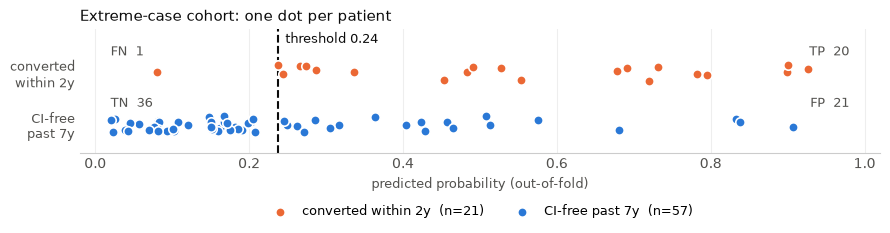

In [370]:
# 78 patients is few enough to draw every one of them, which is more honest
# than a smoothed density built from 21 positives.
POSITIVE, NEGATIVE, INK, MUTED = "#eb6834", "#2a78d6", "#0b0b0b", "#52514e"
jitter = np.random.RandomState(0)

fig, ax = plt.subplots(figsize=(9, 3.2))
for scores, row, color, name in [
    (oof[y == 1], 1, POSITIVE, f"converted within 2y  (n={(y == 1).sum()})"),
    (oof[y == 0], 0, NEGATIVE, f"CI-free past 7y  (n={(y == 0).sum()})"),
]:
    ax.scatter(scores, row + jitter.uniform(-0.16, 0.16, len(scores)), s=46, color=color,
               edgecolor="white", linewidth=1.2, zorder=3, label=name)

ax.axvline(threshold, color=INK, linestyle="--", linewidth=1.5, zorder=2)
ax.text(threshold + 0.01, 1.66, f"threshold {threshold:.2f}", color=INK, fontsize=9, va="center")

# Label each quadrant where its patients actually sit
for x, row, align, text in [(0.02, 1, "left", f"FN  {fn}"), (0.98, 1, "right", f"TP  {tp}"),
                            (0.02, 0, "left", f"TN  {tn}"), (0.98, 0, "right", f"FP  {fp}")]:
    ax.text(x, row + 0.34, text, color=MUTED, fontsize=9, ha=align)

ax.set_yticks([0, 1]); ax.set_yticklabels(["CI-free\npast 7y", "converted\nwithin 2y"], fontsize=9)
ax.set_xlabel("predicted probability (out-of-fold)", fontsize=9, color=MUTED)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.55, 1.85)
ax.set_title("Extreme-case cohort: one dot per patient", fontsize=11, color=INK, loc="left")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.62), ncol=2, frameon=False, fontsize=9)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(length=0, colors=MUTED)
ax.grid(axis="x", color="#eeeeee", zorder=0)
plt.tight_layout()
plt.show()

In [371]:
# The trade-off across candidate thresholds, so the choice above is visible as a choice
rows = []
for t in [0.2, 0.3, threshold, 0.4, 0.5, 0.6, 0.7]:
    tn_, fp_, fn_, tp_ = confusion_matrix(y, (oof >= t).astype(int)).ravel()
    rows.append({"threshold": round(t, 3), "TP": tp_, "FN": fn_, "FP": fp_, "TN": tn_,
                 "sensitivity": tp_ / (tp_ + fn_), "specificity": tn_ / (tn_ + fp_),
                 "precision": tp_ / (tp_ + fp_) if tp_ + fp_ else np.nan})
pd.DataFrame(rows).set_index("threshold").round(2)

,TP,FN,FP,TN,sensitivity,specificity,precision
threshold,,,,,,,
0.200,20,1,24,33,0.95,0.58,0.45
0.300,15,6,15,42,0.71,0.74,0.50
0.237,20,1,21,36,0.95,0.63,0.49
0.400,14,7,12,45,0.67,0.79,0.54
0.500,11,10,7,50,0.52,0.88,0.61
0.600,9,12,4,53,0.43,0.93,0.69
0.700,7,14,3,54,0.33,0.95,0.70


## 7c. Who does the model miss?
The five false negatives - patients who converted within 2 years but scored below the
threshold. With n=5 nothing here can be tested statistically, so this is a description
to generate hypotheses, not a finding.

In [372]:
# Rank every positive by its out-of-fold score. The ones below the threshold are the
# misses; listing all 21 shows where the misses sit relative to the hits.
scored = matched.copy()
scored["risk"] = oof
scored["y"] = y
scored["subtype"] = subtype.reindex(scored["bids_folder"]).values

positives_ranked = scored[scored.y == 1].sort_values("risk")
false_negatives = positives_ranked[positives_ranked.risk <  threshold]
true_positives  = positives_ranked[positives_ranked.risk >= threshold]

positives_ranked[["bids_folder", "site", "Age", "Sex", "Race", "label", "subtype", "risk"]]

,bids_folder,site,Age,Sex,Race,label,subtype,risk
222,sub-I0002150033511,I0002,63,Male,White,613.0,other degenerative,0.079800
448,sub-S0001120573023,S0001,85,Male,White,670.0,unspecified dementia,0.237106
349,sub-S0001121349317,S0001,80,Female,Black,511.0,other degenerative,0.244320
416,sub-I0002150000686,I0002,82,Male,Black,438.0,other degenerative,0.266211
630,sub-S0001111231646,S0001,82,Male,White,601.0,other degenerative,0.274212
307,sub-S0001119718302,S0001,57,Male,White,696.0,other degenerative,0.286523
573,sub-S0001115317921,S0001,70,Female,White,390.0,other degenerative,0.336894
700,sub-S0001118420815,S0001,63,Male,White,712.0,dementia in other disease,0.453470
610,sub-I0006179008513,I0006,77,Female,White,408.0,unspecified dementia,0.483670
754,sub-I0006179001509,I0006,85,Male,White,582.0,unspecified dementia,0.491630


In [373]:
# Are the misses borderline, or decisively missed?
print("positive risk scores, lowest first:")
print(np.round(np.sort(oof[y == 1])[:9], 3))
print(f"\nthreshold {threshold:.3f}")
print(f"positives within 0.03 of the threshold: {(np.abs(oof[y == 1] - threshold) < 0.03).sum()}")

positive risk scores, lowest first:
[0.08  0.237 0.244 0.266 0.274 0.287 0.337 0.453 0.484]

threshold 0.237
positives within 0.03 of the threshold: 3


In [374]:
# Compare the misses to the hits on every subgroup we have
comparison = []
for col in ["Age", "label"]:
    comparison.append([col, round(false_negatives[col].mean(), 1), round(true_positives[col].mean(), 1)])
for col in ["Sex", "Race", "site", "subtype"]:
    comparison.append([col, dict(false_negatives[col].value_counts()), dict(true_positives[col].value_counts())])

# A missing-data explanation would show up here
comparison.append(["missing feature fraction",
                   round(X_matched.isna().mean(axis=1)[y == 1][oof[y == 1] <  threshold].mean(), 3),
                   round(X_matched.isna().mean(axis=1)[y == 1][oof[y == 1] >= threshold].mean(), 3)])

pd.DataFrame(comparison, columns=["", f"false negatives (n={len(false_negatives)})",
                                  f"true positives (n={len(true_positives)})"]).set_index("")

,false negatives (n=1),true positives (n=20)
,,
Age,63.0,72.0
label,613.0,528.6
Sex,{'Male': 1},"{'Male': 14, 'Female': 6}"
Race,{'White': 1},"{'White': 18, 'Black': 2}"
site,{'I0002': 1},"{'S0001': 12, 'I0002': 4, 'I0006': 4}"
subtype,{'other degenerative': 1},"{'other degenerative': 11, 'unspecified dement..."
missing feature fraction,0.037,0.072


## 8a. Age-conditioned AUROC (Challenge 2026 primary metric)
The [George B. Moody PhysioNet Challenge 2026](https://moody-challenge.physionet.org/2026/)
scores submissions with an age-conditioned AUROC rather than a plain one:

> s_C = Pr(z_i >= z_j | x_i, x_j in C with x_i = 1, x_j = 0 such that |a_i - a_j| <= delta)

In words: the probability the model ranks a random positive above a random negative
**of approximately the same age**, using delta = 2 years. Only positive/negative pairs
within 2 years of each other contribute, which stops a model from scoring well by
using age as a proxy for risk.

In [375]:
def age_conditioned_auroc(y_true, scores, ages, delta=2.0):
    """Challenge 2026 primary metric: AUROC over positive/negative pairs matched on age."""
    y_true, scores, ages = np.asarray(y_true), np.asarray(scores, float), np.asarray(ages, float)
    pos_scores, pos_ages = scores[y_true == 1], ages[y_true == 1]
    neg_scores, neg_ages = scores[y_true == 0], ages[y_true == 0]

    comparable = np.abs(pos_ages[:, None] - neg_ages[None, :]) <= delta   # the |a_i - a_j| <= delta gate
    wins = (pos_scores[:, None] > neg_scores[None, :]) + 0.5 * (pos_scores[:, None] == neg_scores[None, :])
    return wins[comparable].mean(), int(comparable.sum())


score, n_pairs = age_conditioned_auroc(y, oof, matched["Age"].values)
print("extreme cases, demographically matched (21 vs 57)")
print(f"  plain AUROC            {roc_auc_score(y, oof):.3f}")
print(f"  age-conditioned AUROC  {score:.3f}   ({n_pairs} comparable pairs of {(y==1).sum()*(y==0).sum()})")

extreme cases, demographically matched (21 vs 57)
  plain AUROC            0.829
  age-conditioned AUROC  0.824   (159 comparable pairs of 1197)


In [376]:
# The same extreme cases before matching, where age is still free to do the work.
unmatched_pos = (d["ci_event"] == True)  & (d["label"] <= FAST_CONVERSION)
unmatched_neg = (d["ci_event"] == False) & (d["label"] >  LONG_CI_FREE)
keep = unmatched_pos | unmatched_neg

X_all, y_all, ages_all = pruned[keep], unmatched_pos[keep].astype(int), d.loc[keep, "Age"].values

oof_all = np.zeros(len(y_all))
for r in range(n_repeats):
    for train, test in StratifiedKFold(5, shuffle=True, random_state=r).split(X_all, y_all):
        fitted_fold = clone(balanced_models["logreg + SMOTE"]).fit(X_all.iloc[train], y_all.iloc[train])
        oof_all[test] += fitted_fold.predict_proba(X_all.iloc[test])[:, 1]
oof_all /= n_repeats

score_all, pairs_all = age_conditioned_auroc(y_all, oof_all, ages_all)
print("extreme cases, NOT matched (21 vs 806)")
print(f"  plain AUROC            {roc_auc_score(y_all, oof_all):.3f}")
print(f"  age-conditioned AUROC  {score_all:.3f}   ({pairs_all} comparable pairs)")

extreme cases, NOT matched (21 vs 806)
  plain AUROC            0.775
  age-conditioned AUROC  0.754   (1782 comparable pairs)


In [377]:
# Does the metric actually neutralise age? Score patients by age alone and see.
summary = []
for label, yy, ss, aa in [
    ("model, matched",     y,     oof,                    matched["Age"].values),
    ("model, unmatched",   y_all, oof_all,                ages_all),
    ("age alone, matched",   y,     matched["Age"].values, matched["Age"].values),
    ("age alone, unmatched", y_all, ages_all,              ages_all),
]:
    summary.append([label, roc_auc_score(yy, ss), age_conditioned_auroc(yy, ss, aa)[0]])

pd.DataFrame(summary, columns=["", "plain AUROC", "age-conditioned AUROC"]).set_index("").round(3)

,plain AUROC,age-conditioned AUROC
,,
"model, matched",0.829,0.824
"model, unmatched",0.775,0.754
"age alone, matched",0.548,0.500
"age alone, unmatched",0.779,0.525


## 8b. Prevalence-based reward (Challenge 2026 secondary metric)

### Why this section exists
The age-conditioned AUROC above only grades the *ranking* of patients. The challenge's
second metric grades the *decisions* a model actually makes, and it weights them by how
common cognitive impairment is at each patient's age:

> p_a = Pr(x = 1 | x in C with |f(x) - a| <= delta), delta = 2 years

| outcome | reward r_k |
|---|---|
| true positive | 1/p_a - 1 |
| true negative | 1/(1 - p_a) - 1 |
| false positive | -1 |
| false negative | -1 |

with the cohort score r_C = mean(r_k). Because CI is rare, a true positive in a
low-prevalence age band is worth a great deal and a true negative almost nothing -
so the metric punishes a model that plays it safe and predicts "no CI" for everyone.

### Why calibration has to come first
Every probability we have produced so far is **miscalibrated**. SMOTE rebalances each
training fold to 50/50, so the model's "0.5" no longer means "50% chance of converting" -
it means "50% under an invented prevalence". This did not matter for AUROC, which only
reads the ordering, but it matters completely here, since the reward depends on which
side of a threshold each patient falls. So we refit without SMOTE and without class
weights (letting the natural ~2.5% prevalence stand) and Platt-scale the output.

In [378]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

def age_local_prevalence(y_true, ages, delta=2.0):
    """p_a: share of positives among patients within delta years of each patient's age."""
    y_true, ages = np.asarray(y_true), np.asarray(ages, float)
    nearby = np.abs(ages[:, None] - ages[None, :]) <= delta
    return (nearby * y_true[None, :]).sum(axis=1) / nearby.sum(axis=1)


def prevalence_reward(y_true, predictions, p_a):
    """Challenge 2026 secondary metric: r_C = mean(r_k)."""
    y_true, predictions = np.asarray(y_true), np.asarray(predictions)
    r = np.where((y_true == 1) & (predictions == 1), 1 / p_a - 1,
        np.where((y_true == 0) & (predictions == 0), 1 / (1 - p_a) - 1, -1.0))
    return r.mean()


y_true_all = y_all.values
p_a = age_local_prevalence(y_true_all, ages_all)
print(f"age-local prevalence: median {np.median(p_a):.3f}, range {p_a.min():.3f}-{p_a.max():.3f}"
      f"  (cohort overall {y_true_all.mean():.3f})")

age-local prevalence: median 0.011, range 0.005-0.429  (cohort overall 0.025)


In [379]:
# The SMOTE model's probabilities, judged as probabilities rather than as a ranking
print("uncalibrated (SMOTE):")
print(f"  mean predicted {oof_all.mean():.3f} vs true prevalence {y_true_all.mean():.3f}"
      f" | Brier {brier_score_loss(y_true_all, oof_all):.4f}")
for t in [0.5, threshold]:
    print(f"  reward at threshold {t:.2f}: {prevalence_reward(y_true_all, (oof_all >= t).astype(int), p_a):.3f}")

uncalibrated (SMOTE):
  mean predicted 0.078 vs true prevalence 0.025 | Brier 0.0461
  reward at threshold 0.50: 0.147
  reward at threshold 0.24: 0.241


In [380]:
# Same features, no resampling, Platt-scaled -> probabilities that mean what they say
calibrated_model = make_pipeline(
    SimpleImputer(strategy="median"), StandardScaler(),
    CalibratedClassifierCV(LogisticRegression(max_iter=2000, C=0.05), method="sigmoid", cv=5))

oof_calibrated = np.zeros(len(y_true_all))
for r in range(n_repeats):
    for train, test in StratifiedKFold(5, shuffle=True, random_state=r).split(X_all, y_all):
        fold = clone(calibrated_model).fit(X_all.iloc[train], y_all.iloc[train])
        oof_calibrated[test] += fold.predict_proba(X_all.iloc[test])[:, 1]
oof_calibrated /= n_repeats

print("calibrated:")
print(f"  mean predicted {oof_calibrated.mean():.4f} vs true prevalence {y_true_all.mean():.4f}"
      f" | Brier {brier_score_loss(y_true_all, oof_calibrated):.4f}")
print(f"  plain AUROC {roc_auc_score(y_true_all, oof_calibrated):.3f}"
      f" | age-conditioned AUROC {age_conditioned_auroc(y_true_all, oof_calibrated, ages_all)[0]:.3f}")

calibrated:
  mean predicted 0.0293 vs true prevalence 0.0254 | Brier 0.0243
  plain AUROC 0.808 | age-conditioned AUROC 0.786


In [381]:
# Sweep the operating point. Trivial strategies are the reference: a model that
# always says "no CI" scores about zero, so anything worth having must beat that.
sweep = pd.DataFrame(
    [(t, prevalence_reward(y_true_all, (oof_calibrated >= t).astype(int), p_a))
     for t in np.round(np.arange(0.01, 0.51, 0.01), 2)], columns=["threshold", "reward"])
best = sweep.loc[sweep.reward.idxmax()]

print(f"best threshold {best.threshold:.2f} -> reward {best.reward:.3f}")
print(f"always-negative baseline {prevalence_reward(y_true_all, np.zeros(len(y_true_all), int), p_a):.3f}"
      f" | always-positive {prevalence_reward(y_true_all, np.ones(len(y_true_all), int), p_a):.3f}")

sweep[sweep.threshold.isin([0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.50])].set_index("threshold").round(3)

best threshold 0.03 -> reward 0.627
always-negative baseline -0.001 | always-positive 0.004


,reward
threshold,
0.01,0.050
0.02,0.447
0.03,0.627
0.05,0.494
0.10,0.124
0.20,-0.009
0.50,-0.002


## 9. The ambiguous middle: patients excluded by the 2-year / 7-year rule
The model was trained only on the clear-cut cases. Three groups were left out and
none of them were ever seen in training, so they are a genuine test set:

| group | definition | n |
|---|---|---|
| late positives | converted, but **after** 2 years | 63 |
| short-follow-up negatives | no CI, but followed **under** 7 years | 200 |
| unmatched negatives | no CI past 7 years, dropped by the demographic matching | 749 |

The question is whether the model has learned "this patient will develop CI" or only
the narrower "this patient is about to develop CI".

In [258]:
# Refit on the full matched cohort - CV is done, so the model can now use all 78
# training patients - then identify the three groups it has never seen.
final_model = clone(balanced_models["logreg + SMOTE"]).fit(X_matched, y_matched)
risk = lambda idx: final_model.predict_proba(pruned.loc[idx])[:, 1]

late_positives   = d.index[(d["ci_event"] == True)  & (d["label"] >  FAST_CONVERSION)]
short_negatives  = d.index[(d["ci_event"] == False) & (d["label"] <= LONG_CI_FREE)]
unmatched_negatives = d.index[(d["ci_event"] == False) & (d["label"] > LONG_CI_FREE)].difference(matched.index)

print(f"late positives             {len(late_positives)}")
print(f"short-follow-up negatives  {len(short_negatives)}")
print(f"negatives dropped by match {len(unmatched_negatives)}")

late positives             63
short-follow-up negatives  200
negatives dropped by match 749


In [259]:
# Mean predicted risk per group. The two training rows are in-sample and therefore
# flattering - they are here only as the reference the model was fitted to.
groups = {
    "positives (training, in-sample)": matched.index[y_matched == 1],
    "late positives (held out)":       late_positives,
    "short-follow-up neg (held out)":  short_negatives,
    "unmatched negatives (held out)":  unmatched_negatives,
    "negatives (training, in-sample)": matched.index[y_matched == 0],
}
for name, idx in groups.items():
    print(f"{name:34s} mean risk {risk(idx).mean():.3f}   (n={len(idx)})")

positives (training, in-sample)    mean risk 0.819   (n=21)
late positives (held out)          mean risk 0.355   (n=63)
short-follow-up neg (held out)     mean risk 0.339   (n=200)
unmatched negatives (held out)     mean risk 0.274   (n=749)
negatives (training, in-sample)    mean risk 0.151   (n=57)


In [260]:
# Can the model separate the held-out groups at all?
for name, (pos_idx, neg_idx) in {
    "late positives vs short-follow-up negatives": (late_positives, short_negatives),
    "late positives vs unmatched negatives":       (late_positives, unmatched_negatives),
}.items():
    scores = np.r_[risk(pos_idx), risk(neg_idx)]
    truth  = np.r_[np.ones(len(pos_idx)), np.zeros(len(neg_idx))]
    print(f"{name:46s} AUC {roc_auc_score(truth, scores):.3f}")

late positives vs short-follow-up negatives    AUC 0.498
late positives vs unmatched negatives          AUC 0.565


In [261]:
# If the model tracked "how soon", risk should fall as time-to-conversion grows.
# Check on the 63 held-out positives only - including the 21 training positives here
# would manufacture the trend, since the model was fitted to score them high.
held_risk = pd.Series(risk(late_positives), index=late_positives)
held_time = d.loc[late_positives, "label"]

print(f"spearman(risk, time-to-event), held-out positives: {held_risk.rank().corr(held_time.rank()):.3f}")
held_risk.groupby(pd.qcut(held_time, 3), observed=True).agg(["mean", "count"])

spearman(risk, time-to-event), held-out positives: -0.093


,mean,count
label,,
"(740.999, 1206.667]",0.362150,21
"(1206.667, 1558.0]",0.410704,21
"(1558.0, 2175.0]",0.292104,21


## 10. Summary

### What the data is

One row per overnight recording, from `all_features_standard.csv`: 1090 recordings,
1090 patients, 3 sites (BIDMC, Emory, Kaiser). 84 patients (7.7%) developed cognitive
impairment during follow-up.

**Features (136 after pruning, from 437 raw).** Sleep physiology only, namespaced by the
pipeline that produced them: `nk__` (HRV / EEG complexity from the raw signals), `rep__`
(clinical-report spectral features), `micro__` (spindles, arousals, CAP), `arch__`
(stage-transition architecture), plus unprefixed summary measures (AHI, TST, sleep
efficiency). **Age, sex, race, BMI and both time columns are excluded** - age deliberately,
since it is the shortcut the whole analysis is built to rule out.

**The cohort is a contrast, not a random sample.** Patients are only included if their
outcome is unambiguous:

| group | definition | n |
|---|---|---|
| positive | developed CI within 2 years | 21 |
| negative | CI-free beyond 7 years | 806 |
| *excluded* | *converted after 2 years* | *63* |
| *excluded* | *CI-free but followed under 7 years* | *200* |

After 1:3 matching on age / sex / race, the modelling cohort is **21 positives vs 57
negatives = 78 patients**.

### Train / test split

There is no held-out test split - with 21 positives, one would be too small to read.
Everything reported is **cross-validated**: 5-fold stratified, repeated 10x, with
imputation, scaling and SMOTE fitted inside each training fold only. Where a single score
per patient is needed (threshold, confusion matrix, subgroups), out-of-fold predictions
are used, so no patient is ever scored by a model that saw them.

The one genuine held-out set is the 263 excluded patients in section 9, who appear in no
training fold at all.

In [ ]:
# Everything in one table. Re-runs the CV rather than trusting numbers printed earlier,
# so the table cannot drift out of sync with the code above it.
rows = []

for name, model in models.items():
    auc = cross_val_score(model, X_all, y_all, cv=cv, scoring="roc_auc")
    rows.append(["unmatched (21 vs 806)", name, len(y_all), auc.mean(), auc.std()])

for name, model in balanced_models.items():
    auc = cross_val_score(model, X_matched, y_matched, cv=cv, scoring="roc_auc")
    rows.append(["matched (21 vs 57)", name, len(y_matched), auc.mean(), auc.std()])

performance = pd.DataFrame(rows, columns=["cohort", "model", "n", "AUROC", "sd"])
performance.round(3)

In [ ]:
# The Challenge metrics, on the cohort the Challenge would actually see (unmatched),
# for each model family. Age-conditioned AUROC needs out-of-fold scores, so we collect
# them per model rather than reusing the single set from section 8.
challenge = []
for name, model in models.items():
    scores = np.zeros(len(y_all))
    for r in range(n_repeats):
        for train, test in StratifiedKFold(5, shuffle=True, random_state=r).split(X_all, y_all):
            scores[test] += clone(model).fit(X_all.iloc[train], y_all.iloc[train]).predict_proba(X_all.iloc[test])[:, 1]
    scores /= n_repeats
    challenge.append([name,
                      roc_auc_score(y_all, scores),
                      age_conditioned_auroc(y_all, scores, ages_all)[0],
                      brier_score_loss(y_all, scores)])

# plus the calibrated model from section 8b, which is the one to submit
challenge.append(["logistic regression (calibrated)",
                  roc_auc_score(y_true_all, oof_calibrated),
                  age_conditioned_auroc(y_true_all, oof_calibrated, ages_all)[0],
                  brier_score_loss(y_true_all, oof_calibrated)])

pd.DataFrame(challenge, columns=["model", "plain AUROC", "age-conditioned AUROC",
                                 "Brier"]).set_index("model").round(3)

### How to read this

- **Age-conditioned AUROC is the number that matters** - it is the Challenge's primary
  metric, and it is the only one that cannot be won by detecting age. For reference, age
  alone scores 0.78 plain but 0.53 age-conditioned.
- **The matched cohort scores higher than the unmatched one** because matching removed
  the hardest comparisons (age-adjacent pairs), not because the model got better.
- **Linear beats boosted here.** With 21 positives and 136 features, LightGBM and random
  forest have far more capacity than the data can constrain; regularised logistic
  regression is the appropriate model at this sample size. LightGBM is worth revisiting
  if the positive window is widened.
- **Every AUROC here carries a fold-to-fold sd of roughly 0.12-0.18.** Differences smaller
  than about 0.05 between models are not real.